In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Utilities
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
df = pd.read_csv("bicimad_users.csv")

# View dataset structure
df.head()

,date,users
0,2014-06-23,99
1,2014-06-24,72
2,2014-06-25,119
3,2014-06-26,135
4,2014-06-27,149


In [3]:
# Inspect dataset
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    3022 non-null   str  
 1   users   3022 non-null   int64
dtypes: int64(1), str(1)
memory usage: 76.9 KB


,users
count,3022.000000
mean,8931.293845
std,3585.677857
min,0.000000
25%,6307.000000
50%,9065.000000
75%,11609.250000
max,17338.000000


In [4]:
# Handle missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [6]:
df.head()

,date,users
0,2014-06-23,99
1,2014-06-24,72
2,2014-06-25,119
3,2014-06-26,135
4,2014-06-27,149


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Example dataset
data = {
    'age': [25, 30, 35, 40],
    'salary': [50000, 60000, 65000, 70000]
}

df = pd.DataFrame(data)

# Define X (features)
X = df[['age', 'salary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.34164079 -1.52127766]
 [-0.4472136  -0.16903085]
 [ 0.4472136   0.50709255]
 [ 1.34164079  1.18321596]]


In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

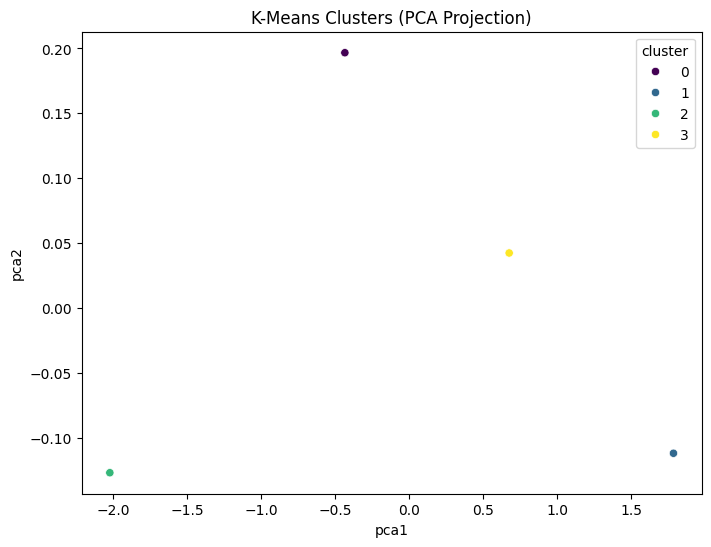

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='viridis'
)

plt.title("K-Means Clusters (PCA Projection)")
plt.show()

In [12]:
print(df.columns)

Index(['age', 'salary', 'cluster', 'pca1', 'pca2'], dtype='str')


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Example text data
documents = ["I love python programming",
             "Machine learning is fun",
             "Python and data science",
             "Clustering text data"]

# Step 1: Vectorize text
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

# Step 2: Train KMeans
kmeans_text = KMeans(n_clusters=3, random_state=42)
kmeans_text.fit(X)

# Step 3: Get feature names
terms = vectorizer.get_feature_names_out()

# Step 4: Find top words per cluster
order_centroids = kmeans_text.cluster_centers_.argsort()[:, ::-1]

for i in range(3):
    print(f"\nCluster {i} top words:")
    for ind in order_centroids[i, :10]:
        print(terms[ind])


Cluster 0 top words:
machine
learning
fun
text
science
python
programming
love
data
clustering

Cluster 1 top words:
data
science
text
clustering
python
programming
machine
love
learning
fun

Cluster 2 top words:
programming
love
python
text
science
machine
learning
fun
data
clustering


In [15]:
df.to_csv("bicimad_users_clustered.csv", index=False)